# Tutorial: PSF y convolución — Laboratorio de Astronomía I

**Unidad 2 — Telescopios**

Este notebook acompaña la **Tarea 2** y responde a la pregunta central del Ejercicio 3:
*¿qué le pasa a la luz de una estrella cuando atraviesa un telescopio real?*

Vamos a construir todo numéricamente, paso a paso, usando **exclusivamente el disco de
Airy** como PSF (sin aproximaciones gaussianas). Trabajamos con imágenes *sintéticas*
(simuladas): el "cielo verdadero" se modela como fuentes puntuales (deltas) con un
flujo dado, tal como se pide en la Tarea 2 — no se descarga ninguna imagen real de un
telescopio, para poder controlar exactamente la física de cada ejemplo.

Contenidos:

1. Qué es una PSF y qué es la convolución (breve repaso conceptual).
2. **Ejemplo 1** — una estrella: cielo real, PSF, imagen convolucionada, y cortes
   radiales que muestran cómo cambia la distribución de la luz.
3. **Ejemplo 2** — un campo con varias estrellas: cómo la convolución puede ocultar
   fuentes que están muy juntas.
4. **Ejemplo 3** — comparación de resoluciones: cómo cambia el ancho y el pico de la
   PSF al variar el diámetro del telescopio, mientras el brillo total (área bajo la
   curva) se mantiene constante.


## 1. ¿Qué es una PSF?

La **PSF** (*Point Spread Function*, función de dispersión de punto) es la imagen que
produce un instrumento óptico de una fuente puntual ideal (una estrella, vista como un
punto sin tamaño angular). Ningún telescopio real forma una imagen perfecta de un
punto: la luz se difracta al pasar por la apertura y se distribuye en un patrón con un
máximo central y anillos concéntricos cada vez más débiles. Para una apertura circular
sin obstrucciones, ese patrón es el **disco de Airy**:

$$
I(\theta) = I_0 \left[\frac{2 J_1(x)}{x}\right]^2, \qquad x = \frac{\pi D \theta}{\lambda}
$$

donde $D$ es el diámetro del telescopio, $\lambda$ la longitud de onda, $\theta$ el
ángulo respecto del centro del patrón, y $J_1$ la función de Bessel de primer orden
(la misma fórmula que se entregó en el Ejercicio 3 de la Tarea 2). El primer mínimo de
este patrón ocurre en $\theta_\mathrm{diff} \approx 1.22\,\lambda/D$: el **límite de
difracción**, el criterio de Rayleigh que ya vieron en la Clase 2A.

## 2. ¿Qué es la convolución?

Toda imagen astronómica real es, en buena aproximación, el resultado de **convolucionar**
el "cielo verdadero" (la distribución real de luz en el cielo, con estrellas puntuales)
con la PSF del sistema completo (telescopio + atmósfera + detector):

$$
\text{Imagen observada} = \text{Cielo verdadero} \; * \; \text{PSF}
$$

Convolucionar significa, intuitivamente, "reemplazar cada punto de luz del cielo
verdadero por una copia (escalada según su brillo) de la PSF, y sumar todas esas copias
superpuestas". Por eso una estrella puntual nunca se ve como un punto en la imagen
final: se ve como la PSF misma. Y si dos estrellas están muy cerca, sus PSFs se
superponen y pueden fundirse en un solo blob, incluso si en el cielo real son dos
fuentes perfectamente separadas.

Una propiedad clave (y muy útil numéricamente) es que la convolución **conserva el
flujo total**: si normalizamos la PSF para que la suma de todos sus píxeles sea 1, la
imagen convolucionada tiene el mismo brillo total que el cielo verdadero, solo que
redistribuido en un área más grande. Vamos a comprobar esto explícitamente en el
Ejemplo 3.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1
from scipy.signal import fftconvolve

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10


## 3. Funciones auxiliares

Definimos tres funciones que vamos a reutilizar en los tres ejemplos:

- `theta_diff_arcsec(D, lam)`: el límite de difracción (criterio de Rayleigh), en
  arcsec, para un telescopio de diámetro `D` a una longitud de onda `lam`.
- `airy_psf(shape, pixel_scale, D, lam)`: construye la PSF de Airy en un grid 2D de
  píxeles, ya **normalizada a suma 1** (para conservar el flujo al convolucionar).
- `make_point_sources(shape, sources, pixel_scale)`: construye una imagen de "cielo
  verdadero" ubicando fuentes puntuales (deltas) en posiciones sub-píxel exactas, con
  el flujo que uno le indique.


In [2]:
def theta_diff_arcsec(D_m, wavelength_m=550e-9):
    '''Límite de difracción (criterio de Rayleigh), en arcsec.'''
    return 1.22 * wavelength_m / D_m * (180 / np.pi * 3600)


def airy_psf(shape, pixel_scale_arcsec, D_m, wavelength_m=550e-9, center=None):
    '''
    PSF de disco de Airy en un grid 2D, normalizada a suma 1 (conserva flujo).

    shape             : (ny, nx) en píxeles
    pixel_scale_arcsec: escala de placa, arcsec/píxel
    D_m               : diámetro del telescopio, en metros
    wavelength_m      : longitud de onda, en metros
    '''
    ny, nx = shape
    if center is None:
        cy, cx = (ny - 1) / 2, (nx - 1) / 2
    else:
        cy, cx = center

    y, x = np.indices((ny, nx))
    r_pix = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    theta_rad = r_pix * pixel_scale_arcsec * (np.pi / 180 / 3600)
    xarg = np.pi * D_m * theta_rad / wavelength_m

    # límite analítico 2*J1(x)/x -> 1 cuando x -> 0 (evita la división por cero)
    with np.errstate(divide="ignore", invalid="ignore"):
        psf = np.where(xarg == 0, 1.0, (2 * j1(xarg) / xarg) ** 2)

    psf = psf / psf.sum()  # normalizar: la convolución conservará el flujo total
    return psf


def make_point_sources(shape, sources, pixel_scale_arcsec):
    '''
    Cielo verdadero: fuentes puntuales ubicadas con precisión sub-píxel.

    sources: lista de (dx_arcsec, dy_arcsec, flujo), offset respecto del centro
             de la imagen.
    Devuelve una imagen (ny, nx) con el flujo de cada fuente repartido por
    interpolación bilineal entre los 4 píxeles vecinos (para no perder precisión
    de posición al redondear a un solo píxel).
    '''
    ny, nx = shape
    cy, cx = (ny - 1) / 2, (nx - 1) / 2
    img = np.zeros(shape)
    for dx_arcsec, dy_arcsec, flux in sources:
        px = cx + dx_arcsec / pixel_scale_arcsec
        py = cy + dy_arcsec / pixel_scale_arcsec
        ix0, iy0 = int(np.floor(px)), int(np.floor(py))
        fx, fy = px - ix0, py - iy0
        for ii, jj, w in [
            (ix0, iy0, (1 - fx) * (1 - fy)),
            (ix0 + 1, iy0, fx * (1 - fy)),
            (ix0, iy0 + 1, (1 - fx) * fy),
            (ix0 + 1, iy0 + 1, fx * fy),
        ]:
            if 0 <= jj < ny and 0 <= ii < nx:
                img[jj, ii] += flux * w
    return img


## 4. Telescopio de referencia

Para los Ejemplos 1 y 2 usamos un telescopio "de referencia" fijo. Elegimos $D = 0.4$ m
(luz visible, $\lambda = 550$ nm) y una escala de placa bien muestreada,
$0.02"/\text{píxel}$, para que la PSF se vea suave en los gráficos.


In [4]:
D_ref = 0.4          # metros
lam = 550e-9          # metros (luz visible)
pixel_scale = 0.02     # arcsec / pixel
grid_shape = (201, 201)

theta_diff_ref = theta_diff_arcsec(D_ref, lam)
print(f"Telescopio de referencia: D = {D_ref} m, lambda = {lam*1e9:.0f} nm")
print(f"Límite de difracción (criterio de Rayleigh): theta_diff = {theta_diff_ref:.3f} arcsec")
print(f"Escala de placa: {pixel_scale} arcsec/pixel  ->  theta_diff = {theta_diff_ref/pixel_scale:.1f} pixeles")


Telescopio de referencia: D = 0.4 m, lambda = 550 nm
Límite de difracción (criterio de Rayleigh): theta_diff = 0.346 arcsec
Escala de placa: 0.02 arcsec/pixel  ->  theta_diff = 17.3 pixeles


## 5. Ejemplo 1 — Una estrella: cielo real, PSF y convolución

Construimos el caso más simple posible: **una sola estrella puntual**. Comparamos tres
imágenes:

1. El **cielo verdadero**: una delta (un punto) con todo el flujo en un único lugar.
2. La **PSF** del telescopio: el disco de Airy.
3. La **imagen convolucionada**: lo que realmente registraría el detector.

Después hacemos un **corte radial** (un corte horizontal que pasa por el centro de la
estrella) para comparar, en el mismo gráfico, cómo se ve la distribución de luz antes y
después de pasar por el telescopio.


In [5]:
# 1. Cielo verdadero: una estrella puntual en el centro, flujo = 1
sky_1 = make_point_sources(grid_shape, sources=[(0.0, 0.0, 1.0)], pixel_scale_arcsec=pixel_scale)

# 2. PSF del telescopio de referencia
psf_1 = airy_psf(grid_shape, pixel_scale, D_ref, lam)

# 3. Imagen observada = cielo verdadero * PSF
conv_1 = fftconvolve(sky_1, psf_1, mode="same")

print(f"Flujo total cielo verdadero:     {sky_1.sum():.6f}")
print(f"Flujo total imagen convolucionada: {conv_1.sum():.6f}   (se conserva)")


Flujo total cielo verdadero:     1.000000
Flujo total imagen convolucionada: 1.000000   (se conserva)


In [8]:
%matplotlib qt
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

extent = np.array([-1, 1, -1, 1]) * grid_shape[0] / 2 * pixel_scale  # arcsec

im0 = axes[0].imshow(sky_1, origin="lower", extent=extent, cmap="inferno")
axes[0].set_title("Cielo verdadero\n(fuente puntual)")

im1 = axes[1].imshow(np.log10(psf_1 + 1e-12), origin="lower", extent=extent, cmap="inferno")
axes[1].set_title("PSF (disco de Airy)\nescala log")

im2 = axes[2].imshow(conv_1, origin="lower", extent=extent, cmap="inferno")
axes[2].set_title("Imagen observada\n(cielo * PSF)")

for ax in axes:
    ax.set_xlabel("arcsec")
    ax.set_ylabel("arcsec")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()


In [ ]:
# Corte radial (horizontal) por el centro de la estrella
cy = grid_shape[0] // 2
angle_axis = (np.arange(grid_shape[1]) - grid_shape[1] // 2) * pixel_scale  # arcsec

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: escala lineal
axes[0].plot(angle_axis, sky_1[cy, :] / sky_1[cy, :].max(), label="Cielo verdadero", lw=2)
axes[0].plot(angle_axis, conv_1[cy, :] / conv_1[cy, :].max(), label="Imagen observada (convolucionada)", lw=2)
axes[0].axvline(theta_diff_ref, color="gray", ls="--", lw=1, label=r"$\theta_{diff}$")
axes[0].axvline(-theta_diff_ref, color="gray", ls="--", lw=1)
axes[0].set_xlim(-1.2, 1.2)
axes[0].set_xlabel("Distancia angular al centro [arcsec]")
axes[0].set_ylabel("Intensidad normalizada")
axes[0].set_title("Corte radial — escala lineal")
axes[0].legend()

# Panel derecho: escala log en y, para ver los anillos débiles del disco de Airy
axes[1].semilogy(angle_axis, psf_1[cy, :] / psf_1[cy, :].max() + 1e-8, label="PSF (Airy)", lw=2, color="C2")
axes[1].axvline(theta_diff_ref, color="gray", ls="--", lw=1, label=r"$\theta_{diff}$")
axes[1].axvline(-theta_diff_ref, color="gray", ls="--", lw=1)
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(1e-6, 2)
axes[1].set_xlabel("Distancia angular al centro [arcsec]")
axes[1].set_ylabel("Intensidad normalizada (log)")
axes[1].set_title("Perfil de la PSF — escala log\n(se ven los anillos de difracción)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Qué observar:** el cielo verdadero es un único píxel con todo el flujo (una
delta). La imagen observada, en cambio, tiene la forma exacta de la PSF: un pico
central ancho y anillos débiles a su alrededor (visibles en escala logarítmica). La
estrella "puntual" nunca se ve como un punto en los datos — se ve como la PSF del
instrumento. Esto es literalmente la definición de convolución: cada fuente puntual del
cielo queda "pintada" con la forma de la PSF.


## 6. Ejemplo 2 — Un campo con varias estrellas: ¿cuándo se ocultan?

Ahora armamos un campo con varias estrellas a distintas separaciones. La idea es
mostrar que, cuando dos fuentes están más cerca entre sí que el límite de difracción
$\theta_\mathrm{diff}$, sus PSFs se solapan tanto que la imagen final las muestra como
un solo blob — aunque en el cielo verdadero sean dos estrellas perfectamente separadas.

Definimos un campo con:
- un **par cerrado**, separado por menos de $\theta_\mathrm{diff}$ (debería fundirse),
- un **par en el límite de Rayleigh**, separado casi exactamente $\theta_\mathrm{diff}$,
- dos estrellas **bien separadas**, muy por encima del límite de difracción.


In [9]:
# Posiciones en arcsec (dx, dy) respecto del centro, y flujo relativo
sources_field = [
    # Par cerrado (separación = 0.4 * theta_diff, en x), centrado en (-0.9, 0.6)
    (-0.9 - 0.2 * theta_diff_ref, 0.6, 1.0),
    (-0.9 + 0.2 * theta_diff_ref, 0.6, 0.8),
    # Par en el límite de Rayleigh (separación = 1.0 * theta_diff), centrado en (0.0, 0.6)
    (0.0 - 0.5 * theta_diff_ref, 0.6, 1.0),
    (0.0 + 0.5 * theta_diff_ref, 0.6, 0.8),
    # Dos estrellas bien separadas (independientes, sin pareja cercana)
    (-0.9, -0.6, 1.0),
    (0.9, -0.6, 0.9),
]

sky_field = make_point_sources(grid_shape, sources_field, pixel_scale)
psf_field = airy_psf(grid_shape, pixel_scale, D_ref, lam)
conv_field = fftconvolve(sky_field, psf_field, mode="same")

print(f"Separación par cerrado:            {0.4*theta_diff_ref:.3f} arcsec  (0.4 x theta_diff)")
print(f"Separación par límite de Rayleigh: {1.0*theta_diff_ref:.3f} arcsec  (1.0 x theta_diff)")
print(f"theta_diff del telescopio de referencia: {theta_diff_ref:.3f} arcsec")


Separación par cerrado:            0.138 arcsec  (0.4 x theta_diff)
Separación par límite de Rayleigh: 0.346 arcsec  (1.0 x theta_diff)
theta_diff del telescopio de referencia: 0.346 arcsec


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
extent = np.array([-1, 1, -1, 1]) * grid_shape[0] / 2 * pixel_scale

im0 = axes[0].imshow(sky_field, origin="lower", extent=extent, cmap="inferno", vmax=sky_field.max())
axes[0].set_title("Cielo verdadero\n(6 estrellas puntuales)")

im1 = axes[1].imshow(conv_field, origin="lower", extent=extent, cmap="inferno")
axes[1].set_title("Imagen observada\n(convolucionada con la PSF)")

labels = [
    (-0.9, 0.9, "par cerrado\n(0.4 x $\\theta_{diff}$)"),
    (0.0, 0.9, "par al límite\n(1.0 x $\\theta_{diff}$)"),
    (0.0, -0.95, "estrellas bien separadas"),
]
for ax in axes:
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    ax.set_xlabel("arcsec")
    ax.set_ylabel("arcsec")
    for lx, ly, txt in labels:
        ax.annotate(txt, (lx, ly), color="white", fontsize=7.5, ha="center", va="bottom")

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()


**Qué observar:** en el cielo verdadero (panel izquierdo) las seis estrellas son
puntos perfectamente distinguibles, incluso el par más cerrado. En la imagen observada
(panel derecho), el par cerrado (separación $0.4\,\theta_\mathrm{diff}$) se funde en un
solo blob alargado — ya no se pueden contar dos estrellas ahí. El par al límite de
Rayleigh ($1.0\,\theta_\mathrm{diff}$) se ve como un blob con una leve "cintura", apenas
resoluble. Las dos estrellas bien separadas, en cambio, siguen viéndose como dos fuentes
independientes. **Esto es exactamente lo que le pasaría a un sistema binario real:** si
su separación angular es menor que $\theta_\mathrm{diff}$ del telescopio, no se puede
resolver como dos estrellas, sin importar cuánta señal se acumule.

Para verlo de forma más cuantitativa, repetimos el experimento con **un solo par de
estrellas**, barriendo la separación entre ellas, y miramos el corte radial en cada
caso.


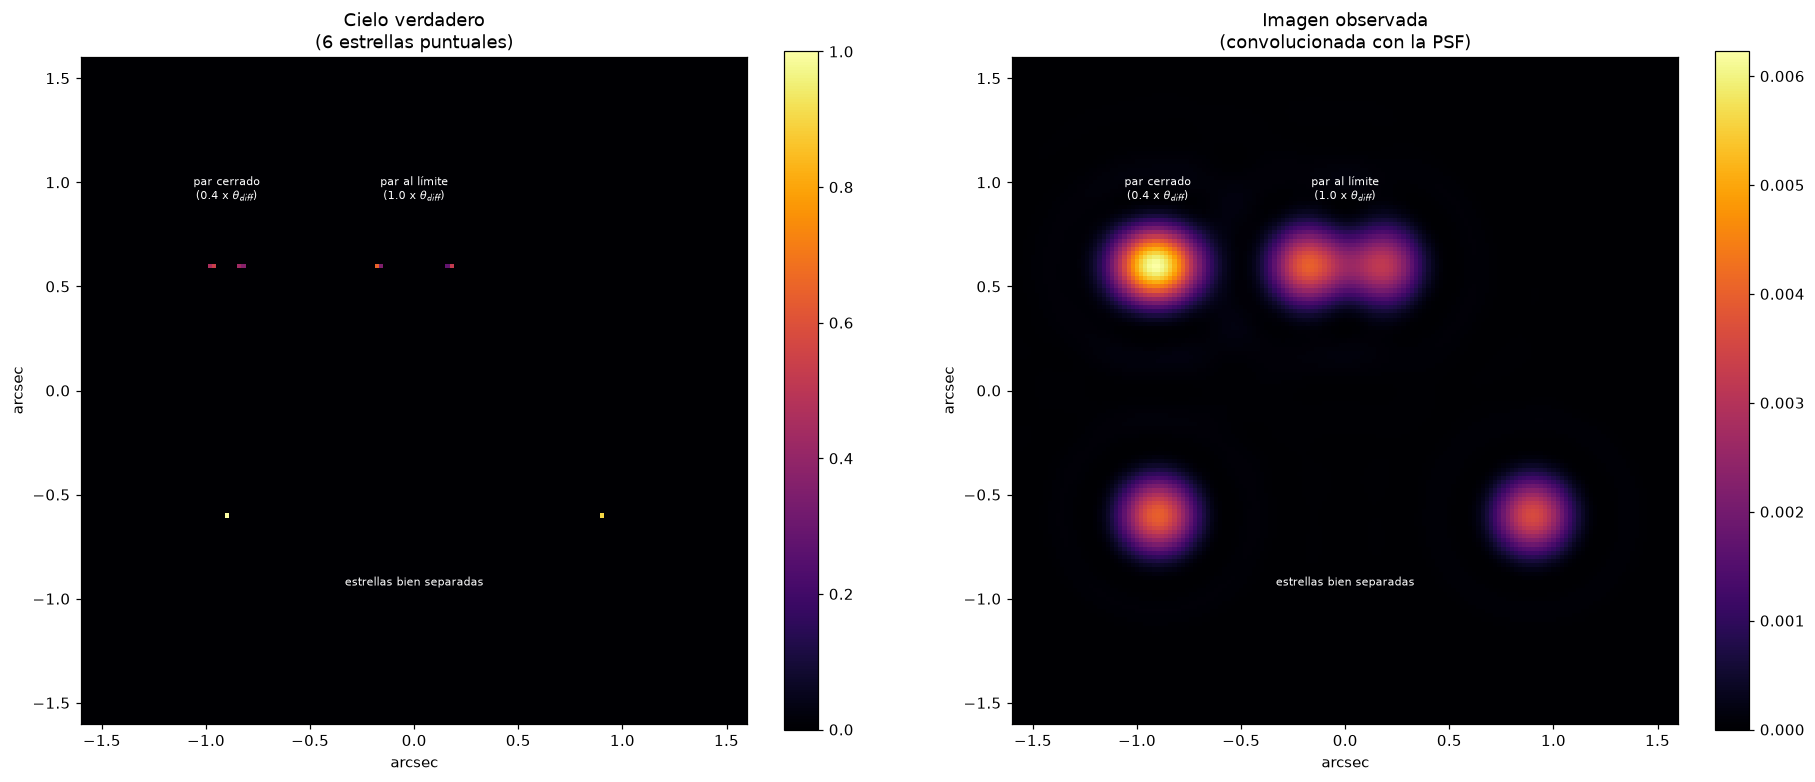

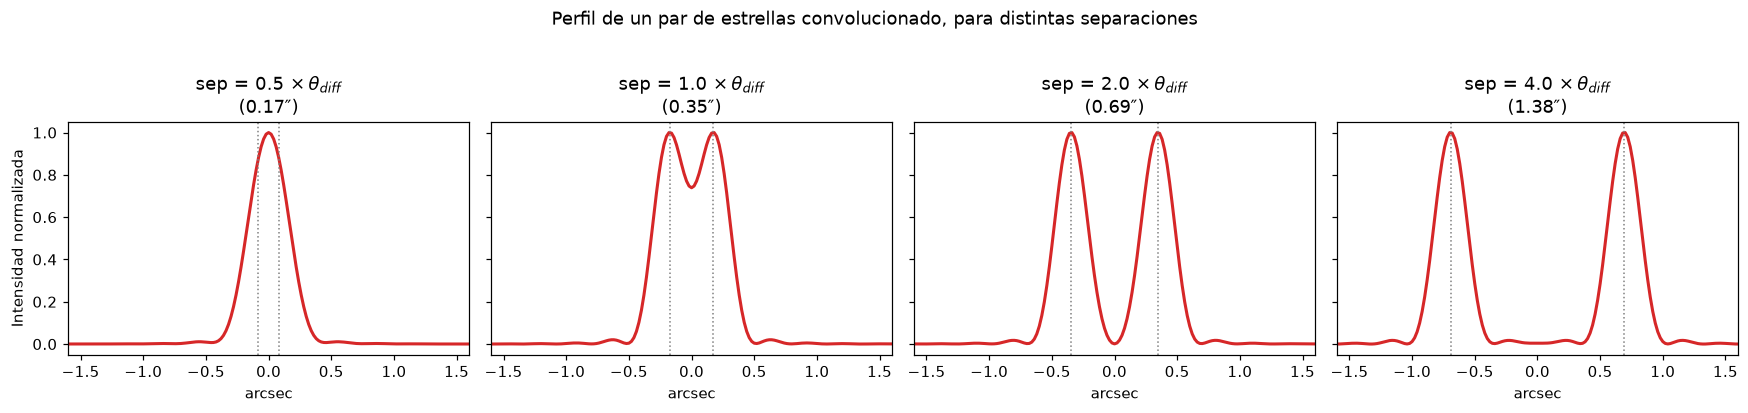

In [13]:
%matplotlib inline
separaciones = np.array([0.5, 1.0, 2.0, 4.0]) * theta_diff_ref
fig, axes = plt.subplots(1, len(separaciones), figsize=(16, 3.6), sharey=True)

angle_axis = (np.arange(grid_shape[1]) - grid_shape[1] // 2) * pixel_scale
cy = grid_shape[0] // 2

for ax, sep in zip(axes, separaciones):
    pair_sky = make_point_sources(
        grid_shape, sources=[(-sep / 2, 0.0, 1.0), (sep / 2, 0.0, 1.0)], pixel_scale_arcsec=pixel_scale
    )
    pair_conv = fftconvolve(pair_sky, psf_field, mode="same")
    perfil = pair_conv[cy, :]
    ax.plot(angle_axis, perfil / perfil.max(), lw=2, color="C3")
    ax.axvline(-sep / 2, color="gray", ls=":", lw=1)
    ax.axvline(sep / 2, color="gray", ls=":", lw=1)
    ax.set_xlim(-1.6, 1.6)
    ax.set_title(f"sep = {sep/theta_diff_ref:.1f} " + r"$\times\,\theta_{diff}$" + f"\n({sep:.2f}″)")
    ax.set_xlabel("arcsec")

axes[0].set_ylabel("Intensidad normalizada")
plt.suptitle("Perfil de un par de estrellas convolucionado, para distintas separaciones", y=1.03)
plt.tight_layout()
plt.show()


**Qué observar:** con separación $0.5\,\theta_\mathrm{diff}$ el perfil muestra un
único máximo — el par no se resuelve, aunque las dos estrellas tengan el mismo brillo.
Con $1.0\,\theta_\mathrm{diff}$ (el criterio de Rayleigh) aparece una leve depresión
central: es el límite convencional de "apenas resuelto". Con separaciones mayores
($2\times$, $4\times$) los dos picos quedan claramente separados por un valle profundo.
Esto es exactamente lo que van a evaluar numéricamente en el Ejercicio 3 de la Tarea 2
con el criterio de Rayleigh.


## 7. Ejemplo 3 — Resolución del telescopio: ancho, pico y flujo conservado

Por último, comparamos **la misma estrella puntual** observada con telescopios de
distinto diámetro $D$ (y por lo tanto, distinta resolución angular), manteniendo fija
la longitud de onda. Usamos tres diámetros: uno chico (baja resolución), uno intermedio
(nuestro telescopio de referencia) y uno grande (alta resolución).

La physics que queremos comprobar: al **bajar la resolución** (achicar $D$), el patrón
de Airy se **ensancha** y su **pico baja** — pero como normalizamos la PSF a suma 1, el
**flujo total** (el área bajo la curva, sumada en 2D) se mantiene igual. La luz de la
estrella no desaparece: solo se reparte en un área más grande.


In [15]:
D_valores = {
    "Baja resolución (D = 0.1 m)": 0.1,
    "Resolución media (D = 0.4 m)": 0.4,
    "Alta resolución (D = 1.6 m)": 1.6,
}

sky_single = make_point_sources(grid_shape, sources=[(0.0, 0.0, 1.0)], pixel_scale_arcsec=pixel_scale)

resultados = {}
for etiqueta, D in D_valores.items():
    psf_D = airy_psf(grid_shape, pixel_scale, D, lam)
    conv_D = fftconvolve(sky_single, psf_D, mode="same")
    resultados[etiqueta] = {
        "D": D,
        "theta_diff": theta_diff_arcsec(D, lam),
        "psf": psf_D,
        "conv": conv_D,
        "pico": conv_D.max(),
        "flujo_total": conv_D.sum(),
    }

header_theta = 'theta_diff [arcsec]'
print(f"{'Telescopio':32s} {'D [m]':>7s} {header_theta:>20s} {'Pico':>10s} {'Flujo total':>12s}")
for etiqueta, r in resultados.items():
    print(f"{etiqueta:32s} {r['D']:7.2f} {r['theta_diff']:20.3f} {r['pico']:10.6f} {r['flujo_total']:12.6f}")


Telescopio                         D [m]  theta_diff [arcsec]       Pico  Flujo total
Baja resolución (D = 0.1 m)         0.10                1.384   0.000271     1.000000
Resolución media (D = 0.4 m)        0.40                0.346   0.004009     1.000000
Alta resolución (D = 1.6 m)         1.60                0.087   0.062896     1.000000


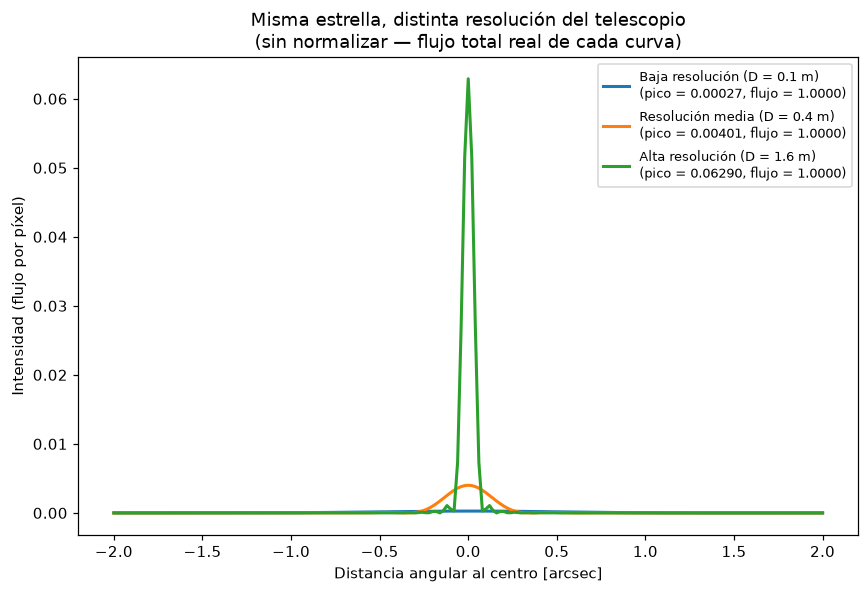

In [16]:
fig, ax = plt.subplots(figsize=(8, 5.5))

angle_axis = (np.arange(grid_shape[1]) - grid_shape[1] // 2) * pixel_scale
cy = grid_shape[0] // 2
colors = ["C0", "C1", "C2"]

for (etiqueta, r), c in zip(resultados.items(), colors):
    perfil = r["conv"][cy, :]
    ax.plot(angle_axis, perfil, label=f"{etiqueta}\n(pico = {r['pico']:.5f}, flujo = {r['flujo_total']:.4f})", color=c, lw=2)

ax.set_xlim(-2.2, 2.2)
ax.set_xlabel("Distancia angular al centro [arcsec]")
ax.set_ylabel("Intensidad (flujo por píxel)")
ax.set_title("Misma estrella, distinta resolución del telescopio\n(sin normalizar — flujo total real de cada curva)")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()


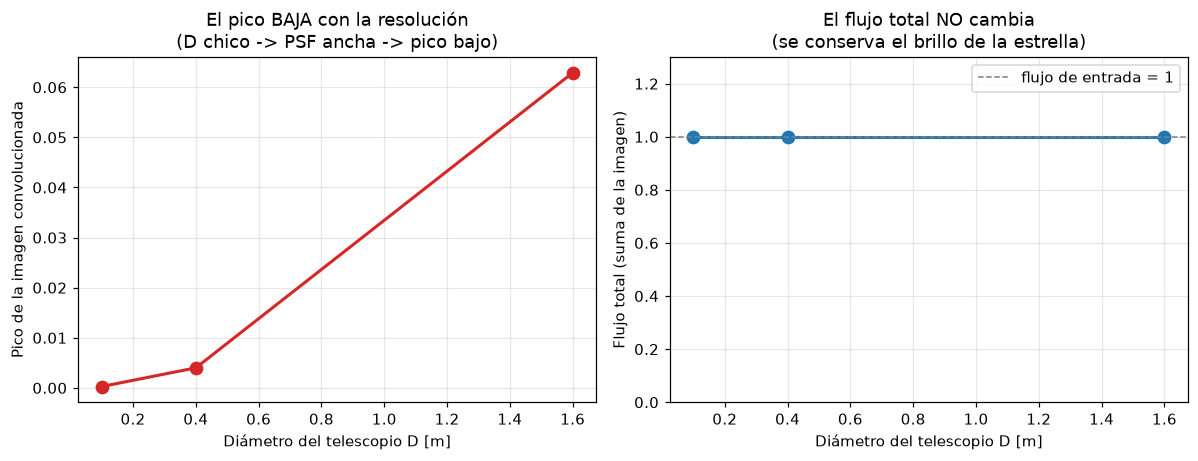

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

D_list = [r["D"] for r in resultados.values()]
pico_list = [r["pico"] for r in resultados.values()]
flujo_list = [r["flujo_total"] for r in resultados.values()]

axes[0].plot(D_list, pico_list, "o-", color="C3", lw=2, markersize=8)
axes[0].set_xlabel("Diámetro del telescopio D [m]")
axes[0].set_ylabel("Pico de la imagen convolucionada")
axes[0].set_title("El pico BAJA con la resolución\n(D chico -> PSF ancha -> pico bajo)")
axes[0].grid(alpha=0.3)

axes[1].plot(D_list, flujo_list, "o-", color="C0", lw=2, markersize=8)
axes[1].set_xlabel("Diámetro del telescopio D [m]")
axes[1].set_ylabel("Flujo total (suma de la imagen)")
axes[1].set_title("El flujo total NO cambia\n(se conserva el brillo de la estrella)")
axes[1].set_ylim(0, 1.3)
axes[1].axhline(1.0, color="gray", ls="--", lw=1, label="flujo de entrada = 1")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Qué observar:** en el gráfico de la izquierda, el pico de la imagen cae
claramente a medida que el telescopio es más chico (peor resolución): la misma cantidad
de luz se reparte en una PSF más ancha, así que cada píxel individual recibe menos
flujo. En el gráfico de la derecha, el **flujo total** (la suma de todos los píxeles,
es decir, el área bajo la curva en 2D) se mantiene esencialmente constante e igual al
flujo de entrada (= 1), sin importar la resolución del telescopio.

En otras palabras: **bajar la resolución no hace que la estrella "pierda brillo"** — el
número total de fotones detectados es el mismo (asumiendo el mismo tiempo de
exposición y área colectora comparable). Lo que cambia es *dónde* cae esa luz: en un
telescopio de baja resolución, la luz de la estrella se reparte sobre un área angular
mayor, se mezcla más fácilmente con la de otras fuentes cercanas (como vimos en el
Ejemplo 2), y resulta más difícil de distinguir de la contribución del cielo de fondo.
Esta es la razón física detrás del Ejercicio 1 de la Tarea 2, donde el límite de
difracción determina cuánto detalle puede realmente resolver un diseño de telescopio.


## 8. Resumen

- La **PSF** es la imagen que un telescopio real forma de una fuente puntual; para una
  apertura circular sin obstrucciones, es el **disco de Airy**,
  $I(\theta) = I_0[2J_1(x)/x]^2$ con $x=\pi D\theta/\lambda$.
- Toda imagen observada es la **convolución** del cielo verdadero con esa PSF: cada
  estrella puntual queda "pintada" con la forma de la PSF.
- Dos fuentes separadas por menos que $\theta_\mathrm{diff}\approx 1.22\,\lambda/D$ se
  **funden** en la imagen convolucionada, aunque sean físicamente distintas en el cielo.
- Al **bajar la resolución** (achicar $D$), la PSF se ensancha y su **pico baja**, pero
  el **flujo total se conserva** — la luz no desaparece, se redistribuye.

**Para pensar (conecta con la Tarea 2):**

1. ¿Qué pasaría con los perfiles del Ejemplo 3 si en vez de variar $D$ variáramos
   $\lambda$? ¿Por qué el color de la luz también afecta la resolución?
2. En el Ejemplo 2, el par "al límite de Rayleigh" mostraba una leve depresión central.
   ¿Qué criterio usarían ustedes, a partir del perfil, para decidir automáticamente
   (sin mirar el gráfico) si dos fuentes están resueltas o no? (Esto es exactamente lo
   que se les pide hacer en el Ejercicio 3 de la Tarea 2.)
3. Si además de la difracción del telescopio hubiera seeing atmosférico (Ejercicio 2 de
   la Tarea 2), ¿la PSF efectiva sería más angosta o más ancha que el disco de Airy
   puro? ¿Cómo esperarían que cambien las conclusiones de este notebook?
